# Understanding PGD: $L_\infty$ vs $L_2$

In this notebook, we study the conceptual and geometric differences between
$L_\infty$-bounded and $L_2$-bounded adversarial perturbations.

We will gradually move from simple low-dimensional examples to CIFAR-10 images
and finally to PGD attacks.

## Goals

- Understand what $L_\infty$ and $L_2$ norms measure.
- Visualize their perturbation sets geometrically.
- Study their behavior in high-dimensional spaces.
- Compare perturbations on real CIFAR-10 images.
- Understand how the choice of norm changes PGD steps and projections.

In [1]:
RUN_ON_COLAB = False

COLAB_PROJECT_ROOT = "/content/drive/MyDrive/pgd_robustness_across_norms"

In [2]:
import sys
from pathlib import Path

if RUN_ON_COLAB:
    from google.colab import drive

    drive.mount("/content/drive")

    PROJECT_ROOT = Path(COLAB_PROJECT_ROOT)

else:
    PROJECT_ROOT = Path.cwd()

    if PROJECT_ROOT.name == "notebooks":
        PROJECT_ROOT = PROJECT_ROOT.parent

PROJECT_ROOT = PROJECT_ROOT.resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

Project root: /home/ali/Desktop/LAB/practical/pgd_robustness_across_norms


In [35]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from src.utils.norms import l2_norm, linf_norm
from src.data.cifar10 import load_cifar10_dataset
from src.attacks.steps import linf_step, l2_step
from src.attacks.projections import project_linf, project_l2

## 1. What is a Norm?

Let $x$ be the original input and $x_{\text{adv}}$ an adversarial input:

$$
x_{\text{adv}} = x + \delta
$$

where $\delta$ is the perturbation.

A norm gives us a way to measure the **size** of $\delta$.

### $L_\infty$ norm

$$
\|\delta\|_\infty = \max_i |\delta_i|
$$

It measures the largest absolute change among all components.

Therefore,

$$
\|\delta\|_\infty \le \epsilon
$$

means that every individual feature is allowed to change by at most $\epsilon$.

---

### $L_2$ norm

$$
\|\delta\|_2 =
\sqrt{\sum_i \delta_i^2}
$$

It measures the overall magnitude of the perturbation.

Therefore,

$$
\|\delta\|_2 \le \epsilon
$$

places a constraint on the total perturbation rather than independently
constraining each feature.

In [4]:
perturbations = {
    "delta_1": torch.tensor([1.0, 0.0]),
    "delta_2": torch.tensor([1.0, 1.0]),
    "delta_3": torch.tensor([0.5, 0.5]),
}

In [5]:
def compare_norms(perturbations):
    rows = []

    for name, delta in perturbations.items():
        rows.append({
            "Perturbation": name,
            "Vector": delta.tolist(),
            "L_inf": round(linf_norm(delta).item(), 2),
            "L2": round(l2_norm(delta).item(), 2),
        })

    return pd.DataFrame(rows)

In [6]:
norm_comparison = compare_norms(perturbations)

norm_comparison

,Perturbation,Vector,L_inf,L2
0,delta_1,"[1.0, 0.0]",1.0,1.00
1,delta_2,"[1.0, 1.0]",1.0,1.41
2,delta_3,"[0.5, 0.5]",0.5,0.71


## 2. Geometry of $L_\infty$ and $L_2$ Constraints

Consider a two-dimensional perturbation

$$
\delta = (\delta_1, \delta_2).
$$

For an $L_\infty$ constraint,

$$
\|\delta\|_\infty \le \epsilon
$$

is equivalent to

$$
|\delta_1| \le \epsilon,
\qquad
|\delta_2| \le \epsilon.
$$

Therefore, the feasible perturbation region is a square.

For an $L_2$ constraint,

$$
\|\delta\|_2 \le \epsilon
$$

means

$$
\delta_1^2 + \delta_2^2 \le \epsilon^2.
$$

Therefore, the feasible perturbation region is a circle.

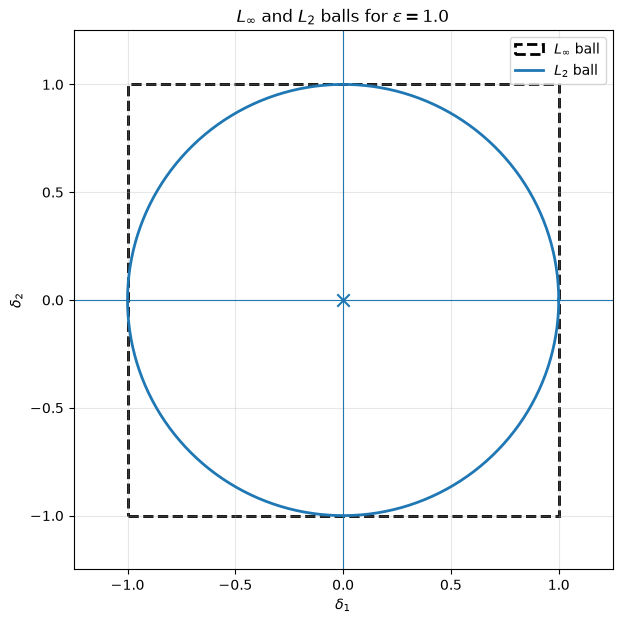

In [7]:
epsilon = 1.0

fig, ax = plt.subplots(figsize=(7, 7))

# L_inf ball
square = plt.Rectangle(
    (-epsilon, -epsilon),
    2 * epsilon,
    2 * epsilon,
    fill=False,
    linewidth=2,
    linestyle="--",
    label=r"$L_\infty$ ball",
)

ax.add_patch(square)

# L2 ball
theta = np.linspace(0, 2 * np.pi, 500)

x_circle = epsilon * np.cos(theta)
y_circle = epsilon * np.sin(theta)

ax.plot(
    x_circle,
    y_circle,
    linewidth=2,
    label=r"$L_2$ ball",
)

ax.scatter(0, 0, marker="x", s=80)

ax.axhline(0, linewidth=0.8)
ax.axvline(0, linewidth=0.8)

limit = 1.25 * epsilon

ax.set_xlim(-limit, limit)
ax.set_ylim(-limit, limit)

ax.set_aspect("equal")

ax.set_xlabel(r"$\delta_1$")
ax.set_ylabel(r"$\delta_2$")

ax.set_title(
    rf"$L_\infty$ and $L_2$ balls for $\epsilon={epsilon}$"
)

ax.grid(alpha=0.3)
ax.legend()

plt.show()

For the same value of $\epsilon$,

$$
B_2(\epsilon)
\subset
B_\infty(\epsilon).
$$

Therefore, changing the norm changes the set of perturbations available to
the adversary.

This distinction will later affect two important components of PGD:

1. the direction of each optimization step,
2. the projection operation after each step.

## 3. Effect of Dimensionality

The difference between $L_\infty$ and $L_2$ becomes much more important
in high-dimensional spaces.

Consider a perturbation where every component has the same magnitude:

$$
\delta = [\epsilon, \epsilon, \ldots, \epsilon].
$$

Its $L_\infty$ norm is always

$$
\|\delta\|_\infty = \epsilon.
$$

However, in a $d$-dimensional space,

$$
\|\delta\|_2
=
\sqrt{
\epsilon^2 + \epsilon^2 + \cdots + \epsilon^2
}
=
\sqrt{d}\epsilon.
$$

Therefore,

$$
\boxed{
\|\delta\|_2 = \sqrt{d}\,\|\delta\|_\infty
}
$$

for this particular perturbation.

This means that many individually small changes can accumulate into
a large $L_2$ perturbation.

In [8]:
epsilon = 8 / 255

dimensions = [
    2,
    10,
    100,
    1000,
    3072, # CIFAR10
]

print(f"epsilon = {epsilon:.6f}")

epsilon = 0.031373


In [9]:
rows = []

for d in dimensions:
    
    delta_dense = torch.full(
        (d,),
        fill_value=epsilon,
        dtype=torch.float32,
    )

    delta_sparse = torch.zeros(
        d,
        dtype=torch.float32,
    )
    delta_sparse[0] = epsilon

    rows.append({
        "Dimension": d,
        "Dense L_inf": linf_norm(delta_dense).item(),
        "Dense L2": l2_norm(delta_dense).item(),
        "Sparse L_inf": linf_norm(delta_sparse).item(),
        "Sparse L2": l2_norm(delta_sparse).item(),
    })

dimension_results = pd.DataFrame(rows)

dimension_results

,Dimension,Dense L_inf,Dense L2,Sparse L_inf,Sparse L2
0,2,0.031373,0.044367,0.031373,0.031373
1,10,0.031373,0.099209,0.031373,0.031373
2,100,0.031373,0.313725,0.031373,0.031373
3,1000,0.031373,0.992087,0.031373,0.031373
4,3072,0.031373,1.738847,0.031373,0.031373


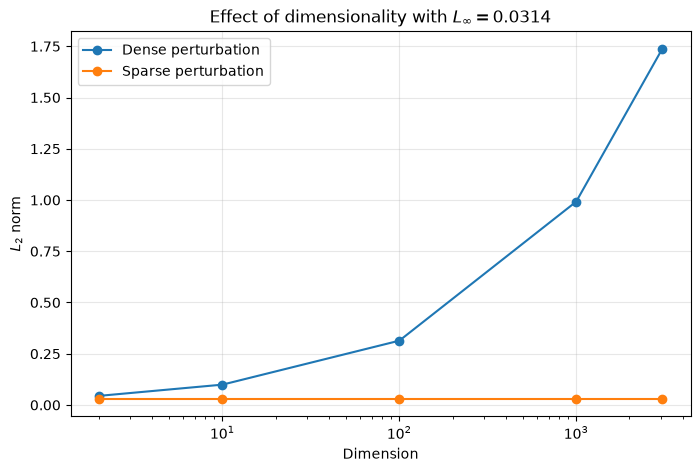

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    dimension_results["Dimension"],
    dimension_results["Dense L2"],
    marker="o",
    label="Dense perturbation",
)

ax.plot(
    dimension_results["Dimension"],
    dimension_results["Sparse L2"],
    marker="o",
    label="Sparse perturbation",
)

ax.set_xscale("log")

ax.set_xlabel("Dimension")
ax.set_ylabel(r"$L_2$ norm")

ax.set_title(
    rf"Effect of dimensionality with $L_\infty = {epsilon:.4f}$"
)

ax.grid(alpha=0.3)
ax.legend()

plt.show()

In [11]:
generator = torch.Generator().manual_seed(42)

rows = []

for d in dimensions:
    delta_random = (
        torch.rand(
            d,
            generator=generator,
        )
        * 2
        - 1
    ) * epsilon

    rows.append({
        "Dimension": d,
        "L_inf": linf_norm(delta_random).item(),
        "L2": l2_norm(delta_random).item(),
    })

random_results = pd.DataFrame(rows)

random_results

,Dimension,L_inf,L2
0,2,0.026039,0.035403
1,10,0.028819,0.060144
2,100,0.031360,0.183308
3,1000,0.031241,0.573764
4,3072,0.031347,0.991787


In [12]:
comparison_rows = []

generator = torch.Generator().manual_seed(42)

for d in dimensions:
    delta_sparse = torch.zeros(d)
    delta_sparse[0] = epsilon

    delta_dense = torch.full(
        (d,),
        epsilon,
    )

    delta_random = (
        torch.rand(
            d,
            generator=generator,
        )
        * 2
        - 1
    ) * epsilon

    comparison_rows.append({
        "Dimension": d,
        "Sparse": l2_norm(delta_sparse).item(),
        "Random": l2_norm(delta_random).item(),
        "Dense": l2_norm(delta_dense).item(),
    })

comparison = pd.DataFrame(comparison_rows)

comparison

,Dimension,Sparse,Random,Dense
0,2,0.031373,0.035403,0.044367
1,10,0.031373,0.060144,0.099209
2,100,0.031373,0.183308,0.313725
3,1000,0.031373,0.573764,0.992087
4,3072,0.031373,0.991787,1.738847


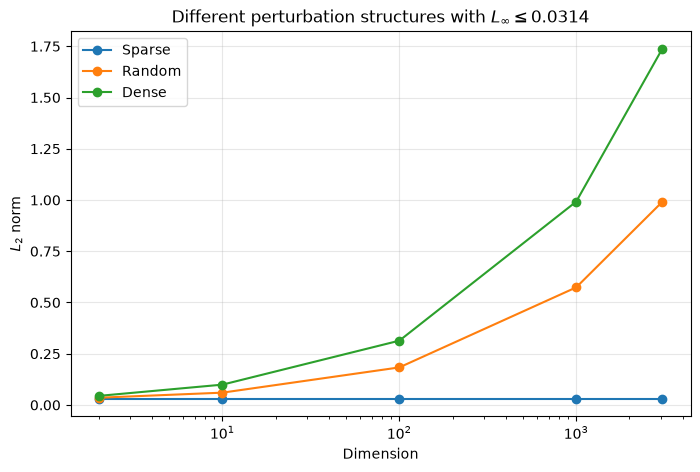

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))

for column in ["Sparse", "Random", "Dense"]:
    ax.plot(
        comparison["Dimension"],
        comparison[column],
        marker="o",
        label=column,
    )

ax.set_xscale("log")

ax.set_xlabel("Dimension")
ax.set_ylabel(r"$L_2$ norm")

ax.set_title(
    rf"Different perturbation structures with $L_\infty \leq {epsilon:.4f}$"
)

ax.grid(alpha=0.3)
ax.legend()

plt.show()

## 4. Perturbations on a Real CIFAR-10 Image

So far, we studied perturbations as abstract vectors.

A CIFAR-10 image has shape

$$
3 \times 32 \times 32
$$

and therefore contains

$$
3 \times 32 \times 32 = 3072
$$

components.

We now apply different perturbations to a real CIFAR-10 image while keeping
the same $L_\infty$ budget.

The goal is to observe how the structure of the perturbation affects its
$L_2$ norm.

In [14]:
DATA_DIR = PROJECT_ROOT / "data"

test_dataset = load_cifar10_dataset(
    root=DATA_DIR,
    train=False,
    download=True,
)

len(test_dataset)

10000

In [15]:
image, label = test_dataset[0]

class_name = test_dataset.classes[label]

print("Shape:", image.shape)
print("Label:", label)
print("Class:", class_name)
print("Min pixel value:", image.min().item())
print("Max pixel value:", image.max().item())

Shape: torch.Size([3, 32, 32])
Label: 3
Class: cat
Min pixel value: 0.05098039284348488
Max pixel value: 1.0


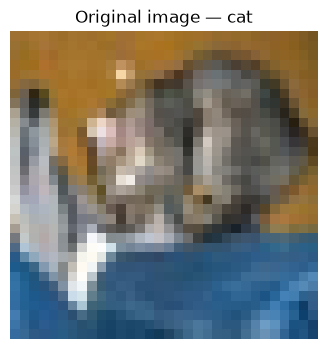

In [16]:
fig, ax = plt.subplots(figsize=(4, 4))

ax.imshow(image.permute(1, 2, 0))
ax.set_title(f"Original image — {class_name}")
ax.axis("off")

plt.show()

In [17]:
epsilon = 8 / 255

generator = torch.Generator().manual_seed(42)

In [18]:
# sparse
delta_sparse = torch.zeros_like(image)
delta_sparse.view(-1)[0] = epsilon

In [19]:
# random
delta_random = (
    torch.rand(
        image.shape,
        generator=generator,
    ) * 2 - 1
) * epsilon

In [20]:
# dense 
random_signs = torch.randint(
    low=0,
    high=2,
    size=image.shape,
    generator=generator,
)

random_signs = random_signs * 2 - 1

delta_dense = random_signs.float() * epsilon

In [21]:
compare_norms({
    "Sparse": delta_sparse,
    "Random": delta_random,
    "Dense": delta_dense,
})

,Perturbation,Vector,L_inf,L2
0,Sparse,"[[[0.0313725508749485, 0.0, 0.0, 0.0, 0.0, 0.0...",0.03,0.03
1,Random,"[[[0.023985523730516434, 0.02603946626186371, ...",0.03,1.00
2,Dense,"[[[-0.0313725508749485, -0.0313725508749485, -...",0.03,1.74


In [22]:
image_sparse = torch.clamp(
    image + delta_sparse,
    0.0,
    1.0,
)

image_random = torch.clamp(
    image + delta_random,
    0.0,
    1.0,
)

image_dense = torch.clamp(
    image + delta_dense,
    0.0,
    1.0,
)

In [23]:
actual_sparse = image_sparse - image
actual_random = image_random - image
actual_dense = image_dense - image

In [24]:
actual_norms = compare_norms({
    "Sparse": actual_sparse,
    "Random": actual_random,
    "Dense": actual_dense,
})

actual_norms

,Perturbation,Vector,L_inf,L2
0,Sparse,"[[[0.0313725471496582, 0.0, 0.0, 0.0, 0.0, 0.0...",0.03,0.03
1,Random,"[[[0.02398550510406494, 0.026039481163024902, ...",0.03,1.00
2,Dense,"[[[-0.0313725471496582, -0.0313725471496582, -...",0.03,1.74


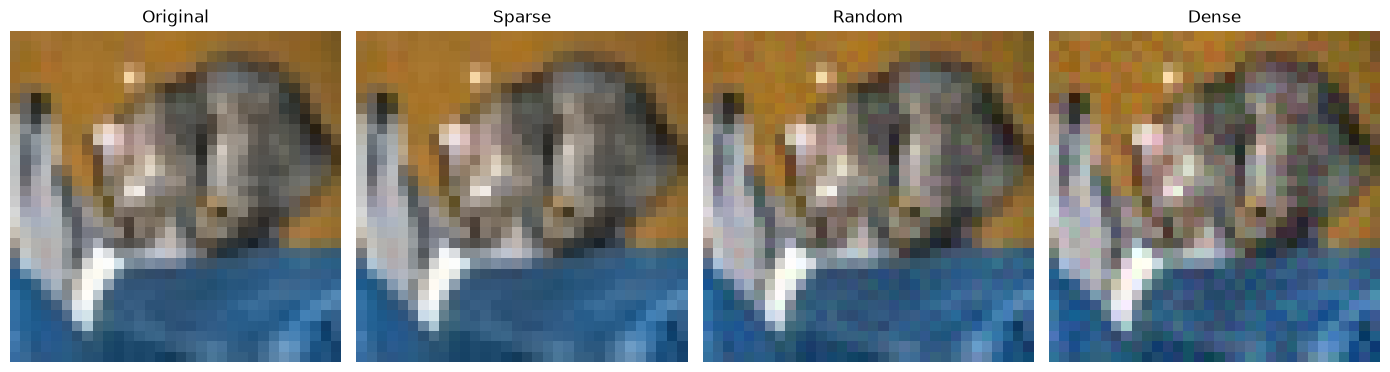

In [25]:
images = {
    "Original": image,
    "Sparse": image_sparse,
    "Random": image_random,
    "Dense": image_dense,
}

fig, axes = plt.subplots(
    1,
    len(images),
    figsize=(14, 4),
)

for ax, (name, img) in zip(axes, images.items()):
    ax.imshow(img.permute(1, 2, 0))
    ax.set_title(name)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [26]:
def perturbation_to_image(delta, epsilon):
    return torch.clamp(
        delta / (2 * epsilon) + 0.5,
        0.0,
        1.0,
    )

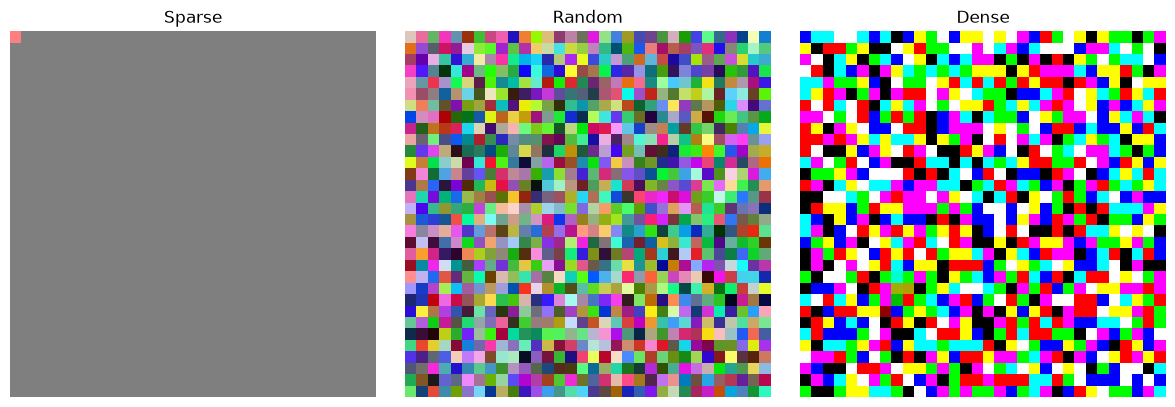

In [27]:
perturbations_to_show = {
    "Sparse": actual_sparse,
    "Random": actual_random,
    "Dense": actual_dense,
}

fig, axes = plt.subplots(
    1,
    3,
    figsize=(12, 4),
)

for ax, (name, delta) in zip(
    axes,
    perturbations_to_show.items(),
):
    ax.imshow(
        perturbation_to_image(
            delta,
            epsilon,
        ).permute(1, 2, 0)
    )

    ax.set_title(name)
    ax.axis("off")

plt.tight_layout()
plt.show()

### Observation

All three perturbations use approximately the same $L_\infty$ budget:

$$
\|\delta\|_\infty \le \frac{8}{255}.
$$

However, their $L_2$ norms are very different.

A sparse perturbation changes only a very small number of components,
so its $L_2$ norm remains small.

A dense perturbation changes almost all 3072 components.
Although every individual change is small, these changes accumulate in
the $L_2$ norm.

Therefore, the structure and dimensionality of the perturbation are important.

## 5. Why Do $L_\infty$ and $L_2$ PGD Use Different Step Directions?

Suppose the loss around the current input $x$ is locally approximated by its
first-order Taylor expansion:

$$
L(x + d)
\approx
L(x) + \nabla_x L(x)^T d.
$$

Let

$$
g = \nabla_x L(x).
$$

To increase the loss as much as possible with one small step, we approximately
solve

$$
\max_d g^T d
$$

subject to a constraint on the step size.

The solution depends on which norm defines the constraint.

In [28]:
gradient = torch.tensor([3.0, 1.0])

step_size = 1.0

In [29]:
step_linf = linf_step(
    gradient,
    step_size=step_size,
)

step_l2 = l2_step(
    gradient,
    step_size=step_size,
)

print("Gradient:", gradient.tolist())
print("L_inf step:", step_linf.tolist())
print("L2 step:", step_l2.tolist())

Gradient: [3.0, 1.0]
L_inf step: [1.0, 1.0]
L2 step: [0.9486832618713379, 0.3162277638912201]


In [30]:
gain_linf = torch.dot(
    gradient,
    step_linf,
).item()

gain_l2 = torch.dot(
    gradient,
    step_l2,
).item()

pd.DataFrame([
    {
        "Step": "L_inf",
        "First-order gain": gain_linf,
    },
    {
        "Step": "L2",
        "First-order gain": gain_l2,
    },
])

,Step,First-order gain
0,L_inf,4.000000
1,L2,3.162277


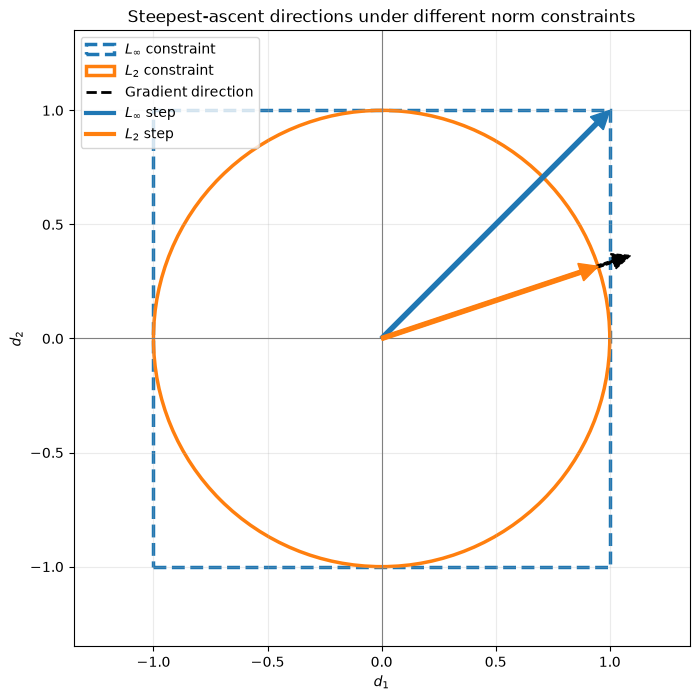

In [31]:
from matplotlib.patches import Circle, Rectangle

fig, ax = plt.subplots(figsize=(8, 8))

# L_inf ball
linf_ball = Rectangle(
    (-step_size, -step_size),
    2 * step_size,
    2 * step_size,
    fill=False,
    edgecolor="tab:blue",
    linestyle="--",
    linewidth=2.5,
    label=r"$L_\infty$ constraint",
)

ax.add_patch(linf_ball)

# L2 ball
l2_ball = Circle(
    (0, 0),
    radius=step_size,
    fill=False,
    edgecolor="tab:orange",
    linestyle="-",
    linewidth=2.5,
    label=r"$L_2$ constraint",
)

ax.add_patch(l2_ball)

gradient_direction = gradient / gradient.norm()

gradient_display = 1.15 * step_size * gradient_direction

ax.arrow(
    0,
    0,
    gradient_display[0].item(),
    gradient_display[1].item(),
    width=0.012,
    head_width=0.07,
    head_length=0.08,
    length_includes_head=True,
    color="black",
    linestyle="--",
    zorder=5,
)

ax.plot(
    [],
    [],
    color="black",
    linestyle="--",
    linewidth=2,
    label="Gradient direction",
)

ax.arrow(
    0,
    0,
    step_linf[0].item(),
    step_linf[1].item(),
    width=0.018,
    head_width=0.08,
    head_length=0.08,
    length_includes_head=True,
    color="tab:blue",
    zorder=6,
)

ax.plot(
    [],
    [],
    color="tab:blue",
    linewidth=3,
    label=r"$L_\infty$ step",
)

ax.arrow(
    0,
    0,
    step_l2[0].item(),
    step_l2[1].item(),
    width=0.018,
    head_width=0.08,
    head_length=0.08,
    length_includes_head=True,
    color="tab:orange",
    zorder=7,
)

ax.plot(
    [],
    [],
    color="tab:orange",
    linewidth=3,
    label=r"$L_2$ step",
)

limit = 1.35 * step_size

ax.set_xlim(-limit, limit)
ax.set_ylim(-limit, limit)

ax.set_aspect("equal")

ax.axhline(0, color="gray", linewidth=0.8)
ax.axvline(0, color="gray", linewidth=0.8)

ax.set_xlabel(r"$d_1$")
ax.set_ylabel(r"$d_2$")

ax.set_title(
    "Steepest-ascent directions under different norm constraints"
)

ax.grid(alpha=0.25)
ax.legend(loc="upper left")

plt.show()

### observation

The gradient contains two types of information:

1. **sign** — whether increasing or decreasing a component increases the loss,
2. **magnitude** — how strongly the loss changes along that component.

Under an $L_\infty$ constraint, each component has its own independent budget.
Therefore, the optimal first-order step pushes every component to its maximum
allowed value in the appropriate direction:

$$
d_{L_\infty}
=
\alpha\,\mathrm{sign}(g).
$$

Under an $L_2$ constraint, all components share a single total budget.
Therefore, the optimal step preserves the relative magnitudes of the gradient:

$$
d_{L_2}
=
\alpha
\frac{g}{\|g\|_2}.
$$

In [54]:
delta = torch.tensor([
    0.2,
    -0.8,
    0.4,
])

epsilon = 0.5

projected = project_linf(
    delta,
    epsilon,
)

print("Original:", delta.tolist())
print("Projected:", projected.tolist())
print("L_inf before:", linf_norm(delta).item())
print("L_inf after:", linf_norm(projected).item())

Original: [0.20000000298023224, -0.800000011920929, 0.4000000059604645]
Projected: [0.20000000298023224, -0.5, 0.4000000059604645]
L_inf before: 0.800000011920929
L_inf after: 0.5


In [55]:
delta = torch.tensor([
    3.0,
    4.0,
])

epsilon = 2.0

projected = project_l2(
    delta,
    epsilon,
)

print("Original:", delta.tolist())
print("Projected:", projected.tolist())
print("L2 before:", l2_norm(delta).item())
print("L2 after:", l2_norm(projected).item())

Original: [3.0, 4.0]
Projected: [1.2000000476837158, 1.600000023841858]
L2 before: 5.0
L2 after: 2.0


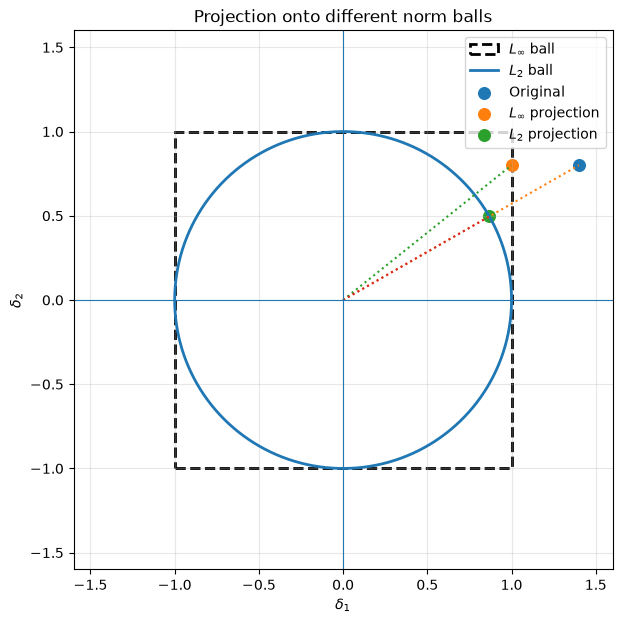

In [57]:
epsilon = 1.0

delta = torch.tensor([
    1.4,
    0.8,
])

delta_linf = project_linf(
    delta,
    epsilon,
)

delta_l2 = project_l2(
    delta,
    epsilon,
)

fig, ax = plt.subplots(figsize=(7, 7))

square = plt.Rectangle(
    (-epsilon, -epsilon),
    2 * epsilon,
    2 * epsilon,
    fill=False,
    linestyle="--",
    linewidth=2,
    label=r"$L_\infty$ ball",
)

ax.add_patch(square)

theta = np.linspace(
    0,
    2 * np.pi,
    500,
)

ax.plot(
    epsilon * np.cos(theta),
    epsilon * np.sin(theta),
    linewidth=2,
    label=r"$L_2$ ball",
)

points = {
    "Original": delta,
    r"$L_\infty$ projection": delta_linf,
    r"$L_2$ projection": delta_l2,
}

for name, point in points.items():
    ax.scatter(
        point[0].item(),
        point[1].item(),
        s=70,
        label=name,
    )

    ax.plot(
        [0, point[0].item()],
        [0, point[1].item()],
        linestyle=":",
    )

limit = 1.6

ax.set_xlim(-limit, limit)
ax.set_ylim(-limit, limit)

ax.set_aspect("equal")

ax.axhline(0, linewidth=0.8)
ax.axvline(0, linewidth=0.8)

ax.set_xlabel(r"$\delta_1$")
ax.set_ylabel(r"$\delta_2$")

ax.set_title("Projection onto different norm balls")

ax.grid(alpha=0.3)
ax.legend()

plt.show()

### observation

Projection is determined by the geometry of the perturbation set.

For $L_\infty$:

$$
\delta_i
\leftarrow
\mathrm{clip}(\delta_i,-\epsilon,\epsilon)
$$

because each component is constrained independently.

For $L_2$:

$$
\delta
\leftarrow
\epsilon
\frac{\delta}{\|\delta\|_2}
$$

when the perturbation is outside the allowed ball.

This preserves the direction of the perturbation while reducing its magnitude.